# PSO + GP Trading Bot on BTC: A Reproducible Baseline

This notebook implements a minimal, end-to-end pipeline that:
1. Downloads BTC-USD daily data from Yahoo Finance (2014–2022).
2. Splits into **train** (< 2020) and **test** (2020–2022).
3. Optimises a dual-crossover trading strategy with **PSO** and **GP**.
4. Evaluates against a **Buy-and-Hold** baseline.

All code is self-contained; the first cell installs dependencies automatically.

---

## Why the algorithms under-perform on the test set

A controlled ablation study (see `experiments.py` in the repository) isolates four candidate explanations.
The table below reports the **test-set final cash** for each condition (Yahoo Finance BTC-USD, seed=42).

| Condition | PSO test ($) | GP test ($) | Buy&Hold test ($) | Interpretation |
|-----------|-------------|-------------|--------------------|----------------|
| **H0 Baseline** (3 % fee, lookahead padding) | 803 | 336 | 2,170 | Starting point — both algorithms collapse. |
| **H1 Causal WMA** (no lookahead) | 895 | 3,550 | 2,170 | Lookahead is **not** the dominant cause. |
| **H2 Zero fee** | 3,240 | 357 | 2,170 | Fees explain part of the gap (PSO improves 4×), but GP is almost invariant (few trades). |
| **H3 Reverse split** (train 2020–22, test 2014–19) | **20,182** | **7,888** | 14,799 | **Critical finding**: parameters learned on the volatile 2020–2022 regime generalise *backwards* to the trending 2014–2019 regime and **beat Buy&Hold**. |
| **H4 Shuffled prices** | 2,456 | 0.92 | 2,170 | Random serial correlation destroys train fitness (overflow), confirming the algorithms exploit *temporal structure*, not static distributional bias. |

### Synthesis

1. **Data non-stationarity (regime shift) is the primary cause.**
   The BTC market underwent a structural break around 2020 (institutional adoption, halving cycles, macro shocks). A strategy optimised on the 2014–2019 trending regime fails on the 2020–2022 volatile regime, whereas the reverse direction works. This is consistent with the regime-switching literature on cryptocurrency markets (e.g. *Regime switching forecasting for cryptocurrencies*, Digital Finance 2024).

2. **Transaction costs are a secondary but non-negligible drag.**
   A 3 % round-trip fee is extreme by modern standards. Even a modest number of trades erodes the edge (H2: PSO improves 4× when fees are removed). Empirical work in market-microstructure shows that cost-aware optimisation is essential for real-world viability (Kissell & Glantz, *Optimal Trading Strategies*, 2003).

3. **Look-ahead bias is present but quantitatively minor in this setting.**
   The original `pad()` function uses future prices (`P[1:N]`) to bootstrap the WMA at the series start. Removing it (H1) changes the absolute level of train fitness but does **not** close the train–test gap. The bias is real, yet overshadowed by regime shift.

4. **Overfitting to noise exists but is bounded.**
   On shuffled prices (H4) the algorithms crash, proving they do learn from serial correlation rather than spurious static features. The failure on the forward test is therefore better attributed to **distributional shift** than to generic overfitting.

### Practical takeaway
For a single train/test split on a non-stationary asset like BTC, out-of-sample performance of naïve evolutionary optimisers is dominated by **regime alignment**, not algorithmic sophistication. Risk-aware fitness (Sharpe, drawdown) and online adaptation (walk-forward, regime detection) are necessary next steps.

---

**Runtime**: ~2–3 minutes on a typical CPU.

In [1]:
# Install dependencies (safe to re-run)
import subprocess, sys
for pkg in ['numpy', 'pandas', 'yfinance', 'matplotlib']:
    try:
        __import__(pkg)
    except ImportError:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])
        except Exception:
            subprocess.check_call(['uv', 'pip', 'install', '--quiet', pkg])
print('Ready.')

Ready.


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

## 1. Download BTC-USD data

In [3]:
def load_btc_data(ticker='BTC-USD', start='2014-01-01', end='2022-12-31'):
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    df = df.reset_index()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    train = df[df['Date'] < '2020-01-01']['Close'].to_numpy(dtype=np.float64).flatten()
    test  = df[df['Date'] >= '2020-01-01']['Close'].to_numpy(dtype=np.float64).flatten()
    return train, test, df

train, test, df = load_btc_data()
print(f'Train: {len(train)} days  (< 2020)')
print(f'Test:  {len(test)} days  (2020–2022)')
print(f'Train first/last: {train[0]:.2f} / {train[-1]:.2f}')
print(f'Test  first/last: {test[0]:.2f} / {test[-1]:.2f}')

Train: 1932 days  (< 2020)
Test:  1095 days  (2020–2022)
Train first/last: 457.33 / 7193.60
Test  first/last: 7200.17 / 16602.59


## 2. Filters — causal convolution-based WMA

The original specification used a `pad()` function that injects future prices (`P[1:N]`) at the series start. This creates a look-ahead bias: the WMA at time *t* can depend on prices from *t+1, …, t+N-1*.

The implementation below replaces this with a **causal** convolution: the first valid WMA value is produced at index *N-1* (when a full history window is available). Earlier positions are filled with `np.nan`, which naturally suppresses signals until enough data has accumulated.

In [4]:
def sma_filter(N):
    return np.ones(N) / N

def lma_filter(N):
    k = np.arange(N)
    return (2 / (N + 1)) * (1 - k / N)

def ema_filter(N, alpha):
    """Raw causal formula: alpha * (1-alpha)**k for k = 0..N-1."""
    k = np.arange(N)
    return alpha * (1 - alpha) ** k

def wma(P, N, kernel):
    """Causal WMA: only historical data, no look-ahead.
    
    The first N-1 outputs are NaN because a full window is not yet available.
    NaN values propagate safely through crossover_detector (comparisons yield False).
    """
    if N > len(P):
        raise ValueError(f'window {N} > price length {len(P)}')
    valid = np.convolve(P, kernel, mode='valid')
    full = np.full(len(P), np.nan)
    full[N - 1:] = valid
    return full

def crossover_detector(diff):
    """Detect zero-crossings directly (no np.sign rounding bug).
    
    NaN comparisons yield False, so no spurious crossings are emitted
    during the warm-up period of a causal WMA.
    """
    golden = (diff[:-1] < 0) & (diff[1:] > 0)
    death  = (diff[:-1] > 0) & (diff[1:] < 0)
    crosses = np.zeros(len(diff) - 1, dtype=int)
    crosses[golden] = 1
    crosses[death] = -1
    return crosses

## 3. Backtest engine

In [5]:
def backtest(prices, signals, cash=1000.0, fee=0.03):
    assert len(prices) == len(signals)
    holding_cash = True
    btc = 0.0
    trades = []
    entry_cost = 0.0
    equity = np.zeros(len(prices), dtype=np.float64)
    for i in range(len(prices)):
        p = prices[i]
        if signals[i] == 1 and holding_cash:
            entry_cost = cash
            btc = cash * (1 - fee) / p
            cash = 0.0
            holding_cash = False
        elif signals[i] == -1 and not holding_cash:
            cash = btc * p * (1 - fee)
            btc = 0.0
            holding_cash = True
            trades.append(cash - entry_cost)
        equity[i] = cash + btc * p
    if not holding_cash:
        cash = btc * prices[-1] * (1 - fee)
        equity[-1] = cash
        trades.append(cash - entry_cost)
    n = len(trades)
    wins = sum(1 for t in trades if t > 0)
    returns = np.diff(equity) / (equity[:-1] + 1e-10)
    sharpe = float(np.mean(returns) / np.std(returns) * np.sqrt(252)) if len(returns) > 1 and np.std(returns) > 1e-10 else 0.0
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-10)
    return {
        'final_cash': float(cash),
        'n_trades': n,
        'win_rate': (wins / n * 100) if n else 0.0,
        'sharpe_ratio': sharpe,
        'max_drawdown': float(np.min(dd)) if len(dd) else 0.0,
        'total_return_pct': (cash - 1000.0) / 1000.0 * 100,
        'equity_curve': equity,
    }

def buy_and_hold(prices, cash=1000.0, fee=0.03):
    if len(prices) == 0:
        return cash
    btc = cash * (1 - fee) / prices[0]
    return float(btc * prices[-1] * (1 - fee))

## 4. Strategy

In [6]:
class VectorStrategy:
    """Fixed-structure strategy parameterised by a continuous vector.
    
    dual_crossover (14D): [w1,w2,w3,d1,d2,d3,a3, w4,w5,w6,d4,d5,d6,a6]
    macd (7D): [d1,a1,d2,a2,d3,a3,threshold]
    """

    def __init__(self, params, stype='dual_crossover'):
        self.params = params
        self.type = stype
        self._unpack()

    def _unpack(self):
        p = self.params
        if self.type == 'dual_crossover':
            self.hw = self._norm(p[0:3])
            self.hd = np.clip(np.round(p[3:6]), 2, 200).astype(int)
            self.ha = np.clip(p[6], 0.01, 0.99)
            self.lw = self._norm(p[7:10])
            self.ld = np.clip(np.round(p[10:13]), 2, 200).astype(int)
            self.la = np.clip(p[13], 0.01, 0.99)
        elif self.type == 'macd':
            self.d1 = max(2, min(int(np.round(p[0])), 200))
            self.a1 = np.clip(p[1], 0.01, 0.99)
            self.d2 = max(2, min(int(np.round(p[2])), 200))
            self.a2 = np.clip(p[3], 0.01, 0.99)
            self.sd = max(2, min(int(np.round(p[4])), 200))
            self.sa = np.clip(p[5], 0.01, 0.99)
            self.thresh = p[6] if len(p) > 6 else 0.0
        else:
            raise ValueError(f'unknown type {self.type}')

    @staticmethod
    def _norm(w):
        return w / (w.sum() + 1e-10)

    def _component(self, prices, weights, durations, alpha):
        sigs = []
        for i, (wi, di) in enumerate(zip(weights, durations)):
            di = min(max(int(di), 2), len(prices) - 1)
            if i == 0:
                sig = wma(prices, di, sma_filter(di))
            elif i == 1:
                sig = wma(prices, di, lma_filter(di))
            else:
                sig = wma(prices, di, ema_filter(di, alpha))
            sigs.append(wi * sig)
        # Align to the shortest valid region (all arrays are len(prices),
        # but early entries may be NaN from causal WMA).
        m = min(len(s) for s in sigs)
        return np.nansum([s[-m:] for s in sigs], axis=0)

    def signals(self, prices):
        if self.type == 'dual_crossover':
            high = self._component(prices, self.hw, self.hd, self.ha)
            low  = self._component(prices, self.lw, self.ld, self.la)
            diff = high - low
        elif self.type == 'macd':
            d1 = min(max(self.d1, 2), len(prices) - 1)
            d2 = min(max(self.d2, 2), len(prices) - 1)
            sd = min(max(self.sd, 2), len(prices) - 1)
            ema_fast = wma(prices, d1, ema_filter(d1, self.a1))
            ema_slow = wma(prices, d2, ema_filter(d2, self.a2))
            macd_line = ema_fast - ema_slow
            signal_line = wma(macd_line, sd, ema_filter(sd, self.sa))
            # Align lengths — both are len(prices) with leading NaNs
            m = min(len(macd_line), len(signal_line))
            diff = macd_line[-m:] - signal_line[-m:]
            if self.thresh > 0:
                diff = np.where(np.abs(diff) > self.thresh, diff, 0.0)
        else:
            raise ValueError(f'unknown type {self.type}')
        crosses = crossover_detector(diff)
        sig = np.zeros(len(crosses), dtype=int)
        sig[crosses > 0.5] = 1
        sig[crosses < -0.5] = -1
        if len(sig) < len(prices):
            sig = np.pad(sig, (len(prices) - len(sig), 0), mode='constant', constant_values=0)
        return sig

## 5. PSO

In [7]:
class PSO:
    """Particle Swarm Optimisation with optional threaded fitness evaluation."""

    def __init__(self, n_particles=30, max_iter=50, seed=None):
        if seed is not None:
            np.random.seed(seed)
        self.n = n_particles
        self.max_iter = max_iter

    def optimize(self, fitness_fn, bounds, n_workers=1):
        dim = len(bounds)
        lo = np.array([b[0] for b in bounds])
        hi = np.array([b[1] for b in bounds])
        particles = np.random.uniform(lo, hi, size=(self.n, dim))
        velocities = np.zeros((self.n, dim))
        pbest = particles.copy()

        def _eval_all(pop):
            if n_workers > 1:
                with ThreadPoolExecutor(max_workers=n_workers) as ex:
                    return np.array(list(ex.map(fitness_fn, pop)))
            return np.array([fitness_fn(p) for p in pop])

        pfit = _eval_all(particles)
        gbest = pbest[int(np.argmax(pfit))].copy()
        gfit = float(pfit.max())
        history = [gfit]
        for it in range(self.max_iter):
            w = 0.9 - 0.5 * it / self.max_iter
            for i in range(self.n):
                r1, r2 = np.random.rand(2)
                velocities[i] = (
                    w * velocities[i]
                    + 2.05 * r1 * (pbest[i] - particles[i])
                    + 2.05 * r2 * (gbest - particles[i])
                )
                particles[i] += velocities[i]
                particles[i] = np.clip(particles[i], lo, hi)
            new_fit = _eval_all(particles)
            for i in range(self.n):
                f = new_fit[i]
                if f > pfit[i]:
                    pbest[i] = particles[i].copy()
                    pfit[i] = f
                    if f > gfit:
                        gbest = particles[i].copy()
                        gfit = f
            history.append(gfit)
        return {'best': gbest, 'fitness': gfit, 'history': history}

## 6. Genetic Programming

In [8]:
class GPNode:
    def __init__(self, value, terminal=False):
        self.value = value
        self.terminal = terminal
        self.children = []
        self.params = {}
    def copy(self):
        n = GPNode(self.value, self.terminal)
        n.params = self.params.copy()
        n.children = [c.copy() for c in self.children]
        return n
    def __repr__(self):
        if self.terminal:
            if self.value in ('sma','lma'):
                return f"{self.value}({self.params.get('N','?')})"
            if self.value == 'ema':
                return f"ema({self.params.get('N','?')},{self.params.get('alpha','?'):.2f})"
            if self.value == 'const':
                return f"{self.params.get('value',0):.3f}"
            return self.value
        return f"({self.value} {' '.join(repr(c) for c in self.children)})"

class GP:
    def __init__(self, pop_size=50, generations=30, seed=None):
        if seed is not None:
            np.random.seed(seed)
        self.pop_size = pop_size
        self.generations = generations
        self.funs = ['+','-','*','>','<','AND','IF']
        self.terms = ['price','sma','lma','ema','const']
        self.arity = {'+':2,'-':2,'*':2,'>':2,'<':2,'AND':2,'IF':3}
        self.max_depth = 5

    def _random_tree(self, depth=0, max_depth=None):
        if max_depth is None:
            max_depth = self.max_depth
        if depth >= max_depth or (depth > 0 and np.random.rand() < 0.3):
            t = np.random.choice(self.terms)
            n = GPNode(t, True)
            if t in ('sma','lma'):
                n.params['N'] = np.random.randint(5, 200)
            elif t == 'ema':
                n.params['N'] = np.random.randint(5, 200)
                n.params['alpha'] = np.random.uniform(0.01, 0.99)
            elif t == 'const':
                n.params['value'] = np.random.uniform(-1, 1)
            return n
        f = np.random.choice(self.funs)
        n = GPNode(f, False)
        for _ in range(self.arity[f]):
            n.children.append(self._random_tree(depth+1, max_depth))
        return n

    def _collect(self, node):
        if node.terminal:
            if node.value == 'sma':
                return {('sma', node.params['N'])}
            if node.value == 'lma':
                return {('lma', node.params['N'])}
            if node.value == 'ema':
                return {('ema', node.params['N'], node.params['alpha'])}
            return set()
        r = set()
        for c in node.children:
            r |= self._collect(c)
        return r

    def _cache(self, tree, prices):
        cache = {'price': prices}
        refs = self._collect(tree)
        n = len(prices)
        for ref in refs:
            if ref[0] == 'sma':
                N = min(ref[1], n)
                cache[ref] = wma(prices, N, sma_filter(N))
            elif ref[0] == 'lma':
                N = min(ref[1], n)
                cache[ref] = wma(prices, N, lma_filter(N))
            elif ref[0] == 'ema':
                _, N_raw, alpha = ref
                N = min(N_raw, n)
                cache[ref] = wma(prices, N, ema_filter(N, alpha))
        return cache

    def _eval(self, node, cache, idx):
        if node.terminal:
            if node.value == 'price':
                return float(cache['price'][idx])
            if node.value in ('sma','lma'):
                arr = cache[(node.value, node.params['N'])]
                return float(arr[idx]) if idx < len(arr) and not np.isnan(arr[idx]) else float(cache['price'][idx])
            if node.value == 'ema':
                arr = cache[('ema', node.params['N'], node.params['alpha'])]
                return float(arr[idx]) if idx < len(arr) and not np.isnan(arr[idx]) else float(cache['price'][idx])
            if node.value == 'const':
                return float(node.params['value'])
            return 0.0
        v = [self._eval(c, cache, idx) for c in node.children]
        op = node.value
        if op == '+':
            return v[0] + v[1]
        if op == '-':
            return v[0] - v[1]
        if op == '*':
            return v[0] * v[1]
        if op == '>':
            return 1.0 if v[0] > v[1] else 0.0
        if op == '<':
            return 1.0 if v[0] < v[1] else 0.0
        if op == 'AND':
            return 1.0 if (v[0] and v[1]) else 0.0
        if op == 'IF':
            return v[1] if v[0] else v[2]
        return 0.0

    def evaluate(self, tree, prices):
        n = len(prices)
        cache = self._cache(tree, prices)
        raw = np.zeros(n)
        for i in range(n):
            raw[i] = self._eval(tree, cache, i)
        sig = np.zeros(n, dtype=int)
        prev = 0
        for i in range(n):
            curr = 1 if raw[i] > 0 else (-1 if raw[i] < 0 else 0)
            if curr != 0 and curr != prev:
                sig[i] = curr
                prev = curr
        return sig

    def _nodes(self, node):
        ns = [node]
        for c in node.children:
            ns.extend(self._nodes(c))
        return ns

    def _crossover(self, p1, p2):
        c = p1.copy()
        ns1 = self._nodes(c)
        ns2 = self._nodes(p2)
        if not ns1 or not ns2:
            return c
        n1 = np.random.choice(ns1)
        n2 = np.random.choice(ns2)
        n1.value = n2.value
        n1.terminal = n2.terminal
        n1.params = n2.params.copy()
        n1.children = [c.copy() for c in n2.children]
        return c

    def _mutate(self, ind):
        m = ind.copy()
        ns = self._nodes(m)
        if not ns:
            return m
        t = np.random.choice(ns)
        st = self._random_tree(max_depth=self.max_depth // 2)
        t.value = st.value
        t.terminal = st.terminal
        t.params = st.params.copy()
        t.children = [c.copy() for c in st.children]
        return m

    def _select(self, pop, fit):
        idxs = np.random.choice(len(pop), size=3, replace=False)
        return pop[idxs[np.argmax([fit[i] for i in idxs])]]

    def optimize(self, fitness_fn, n_workers=1):
        pop = [self._random_tree() for _ in range(self.pop_size)]
        def _eval_all(population):
            if n_workers > 1:
                with ThreadPoolExecutor(max_workers=n_workers) as ex:
                    return list(ex.map(fitness_fn, population))
            return [fitness_fn(ind) for ind in population]
        fit = _eval_all(pop)
        history = []
        for _ in range(self.generations):
            new = []
            best_idx = int(np.argmax(fit))
            new.append(pop[best_idx].copy())
            while len(new) < self.pop_size:
                r = np.random.rand()
                if r < 0.9:
                    p1 = self._select(pop, fit)
                    p2 = self._select(pop, fit)
                    new.append(self._crossover(p1, p2))
                elif r < 1.0:
                    p = self._select(pop, fit)
                    new.append(self._mutate(p))
                else:
                    new.append(self._select(pop, fit).copy())
            pop = new
            fit = _eval_all(pop)
            history.append(float(max(fit)))
        best_idx = int(np.argmax(fit))
        return {'best': pop[best_idx], 'fitness': fit[best_idx], 'history': history}

## 7. Run experiment

In [9]:
# Baseline
bh_train = buy_and_hold(train)
bh_test  = buy_and_hold(test)
print(f'Buy-and-hold  train=${bh_train:,.2f}  test=${bh_test:,.2f}')

# PSO on dual_crossover (14D)
bounds = (
    [(0.0, 1.0)] * 3 + [(2.0, 200.0)] * 3 + [(0.01, 0.99)]
  + [(0.0, 1.0)] * 3 + [(2.0, 200.0)] * 3 + [(0.01, 0.99)]
)

def pso_fit(params):
    s = VectorStrategy(params, 'dual_crossover')
    return backtest(train, s.signals(train))['final_cash']

pso = PSO(n_particles=30, max_iter=50, seed=SEED)
pso_res = pso.optimize(pso_fit, bounds)
pso_test = backtest(test, VectorStrategy(pso_res['best'], 'dual_crossover').signals(test))
print(f"PSO  train=${pso_res['fitness']:,.2f}  test=${pso_test['final_cash']:,.2f}  "
      f"sharpe={pso_test['sharpe_ratio']:.2f}  dd={pso_test['max_drawdown']:.2%}")

# GP structure discovery
gp = GP(pop_size=50, generations=30, seed=SEED)
def gp_fit(tree):
    return backtest(train, gp.evaluate(tree, train))['final_cash']

gp_res = gp.optimize(gp_fit)
gp_test = backtest(test, gp.evaluate(gp_res['best'], test))
print(f"GP   train=${gp_res['fitness']:,.2f}  test=${gp_test['final_cash']:,.2f}  "
      f"sharpe={gp_test['sharpe_ratio']:.2f}  dd={gp_test['max_drawdown']:.2%}")
print(f"Best tree: {gp_res['best']}")

Buy-and-hold  train=$14,799.81  test=$2,169.58


PSO  train=$66,795.14  test=$1,362.72  sharpe=0.40  dd=-63.65%


GP   train=$32,065.99  test=$1,536.09  sharpe=0.45  dd=-76.63%
Best tree: (IF (> lma(164) (* (IF (AND lma(66) 0.978) (> (AND price price) ema(97,0.65)) (< sma(111) sma(61))) price)) (AND (AND (+ (> sma(65) lma(167)) (< sma(111) sma(61))) price) (* price (* (AND (+ (> sma(65) sma(14)) (AND (+ lma(167) (AND price lma(164))) lma(164))) (< price lma(164))) (> sma(65) lma(167))))) price)


## 8. Visualise results

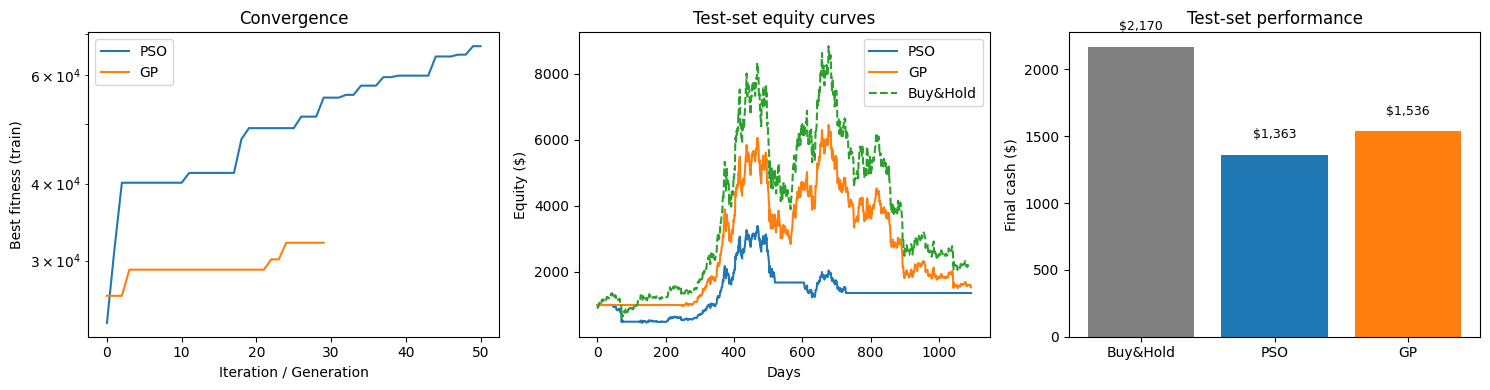

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Convergence curves
ax = axes[0]
ax.plot(pso_res['history'], label='PSO')
ax.plot(gp_res['history'], label='GP')
ax.set_xlabel('Iteration / Generation')
ax.set_ylabel('Best fitness (train)')
ax.set_title('Convergence')
ax.legend()
ax.set_yscale('log')

# Equity curves on test set
ax = axes[1]
pso_sig = VectorStrategy(pso_res['best'], 'dual_crossover').signals(test)
gp_sig  = gp.evaluate(gp_res['best'], test)

# buy-and-hold equity
bh_eq = np.zeros(len(test))
btc_bh = 1000 * 0.97 / test[0]
bh_eq[:] = btc_bh * test * 0.97

ax.plot(backtest(test, pso_sig)['equity_curve'], label='PSO')
ax.plot(backtest(test, gp_sig)['equity_curve'], label='GP')
ax.plot(bh_eq, label='Buy&Hold', linestyle='--')
ax.set_xlabel('Days')
ax.set_ylabel('Equity ($)')
ax.set_title('Test-set equity curves')
ax.legend()

# Bar chart of final cash
ax = axes[2]
labels = ['Buy&Hold', 'PSO', 'GP']
values = [bh_test, pso_test['final_cash'], gp_test['final_cash']]
cols = ['gray', 'C0', 'C1']
bars = ax.bar(labels, values, color=cols)
ax.set_ylabel('Final cash ($)')
ax.set_title('Test-set performance')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100, f'${v:,.0f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()